## Offline inference

In [5]:
!pip uninstall -y pillow
!pip install -q \
  pillow==10.2.0 \
  transformers \
  faiss-cpu \
  datasets \
  huggingface_hub

Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0


In [6]:
import torch
print("CUDA:", torch.cuda.is_available())

CUDA: True


In [7]:
from huggingface_hub import snapshot_download
import os

DATASET_DIR = "/content/llava_bench"

snapshot_download(
    repo_id="liuhaotian/llava-bench-in-the-wild",
    repo_type="dataset",
    local_dir=DATASET_DIR,
    local_dir_use_symlinks=False
)

print("Images:", os.listdir(f"{DATASET_DIR}/images")[:5])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 31 files:   0%|          | 0/31 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

context.jsonl: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

images/022.jpg:   0%|          | 0.00/95.6k [00:00<?, ?B/s]

images/023.jpg:   0%|          | 0.00/40.2k [00:00<?, ?B/s]

questions.jsonl: 0.00B [00:00, ?B/s]

images/024.jpg:   0%|          | 0.00/252k [00:00<?, ?B/s]

Images: ['024.jpg', '017.jpg', '016.jpg', '003.jpg', '010.jpg']


In [8]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("CLIP loaded OK")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded OK


In [9]:
def embed_text(texts):
    inputs = processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        emb = model.get_text_features(**inputs)

    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")

In [10]:
def embed_images(images):
    inputs = processor(
        images=images,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        emb = model.get_image_features(**inputs)

    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")

In [11]:
import glob
import faiss

images_dir = f"{DATASET_DIR}/images"
img_paths = sorted(glob.glob(f"{images_dir}/*.jpg"))

pil_images = [
    Image.open(p).convert("RGB")
    for p in img_paths
]

img_embeddings = embed_images(pil_images)

dim = img_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(img_embeddings)

print("FAISS size:", index.ntotal)

FAISS size: 24


In [12]:
def search_by_text(query, k=5):
    q_emb = embed_text([query])
    scores, ids = index.search(q_emb, k)
    return [(img_paths[i], scores[0][r]) for r, i in enumerate(ids[0])]

In [13]:
results = search_by_text("a dog", 5)
results

[('/content/llava_bench/images/003.jpg', np.float32(0.280739)),
 ('/content/llava_bench/images/014.jpg', np.float32(0.2423572)),
 ('/content/llava_bench/images/017.jpg', np.float32(0.23505722)),
 ('/content/llava_bench/images/005.jpg', np.float32(0.22254013)),
 ('/content/llava_bench/images/018.jpg', np.float32(0.21354063))]

In [14]:
import matplotlib.pyplot as plt
import os

def show(results, title):
    plt.figure(figsize=(14,4))
    for i, (path, score) in enumerate(results):
        img = Image.open(path)
        ax = plt.subplot(1, len(results), i+1)
        ax.imshow(img)
        ax.set_title(f"{os.path.basename(path)}\n{score:.3f}")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

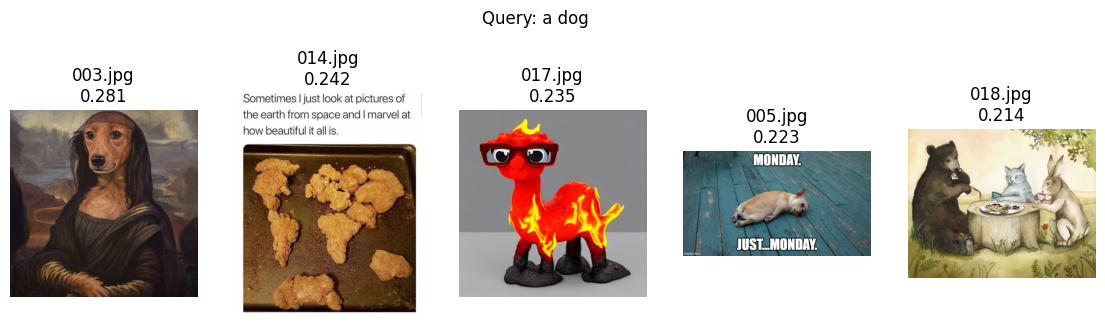

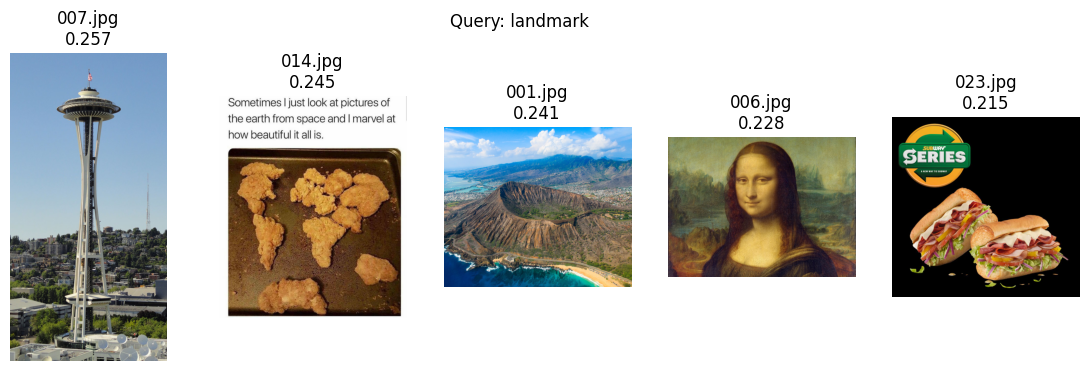

In [16]:
show(search_by_text("a dog", 5), "Query: a dog")
show(search_by_text("famous landmark travel", 5), "Query: landmark")

### Small practice: ẢNH CON CHÓ → ẢNH TƯƠNG TỰ

In [21]:
!curl -L "https://upload.wikimedia.org/wikipedia/commons/1/18/Dog_Breeds.jpg" -o dog_url.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 70761  100 70761    0     0   442k      0 --:--:-- --:--:-- --:--:--  442k


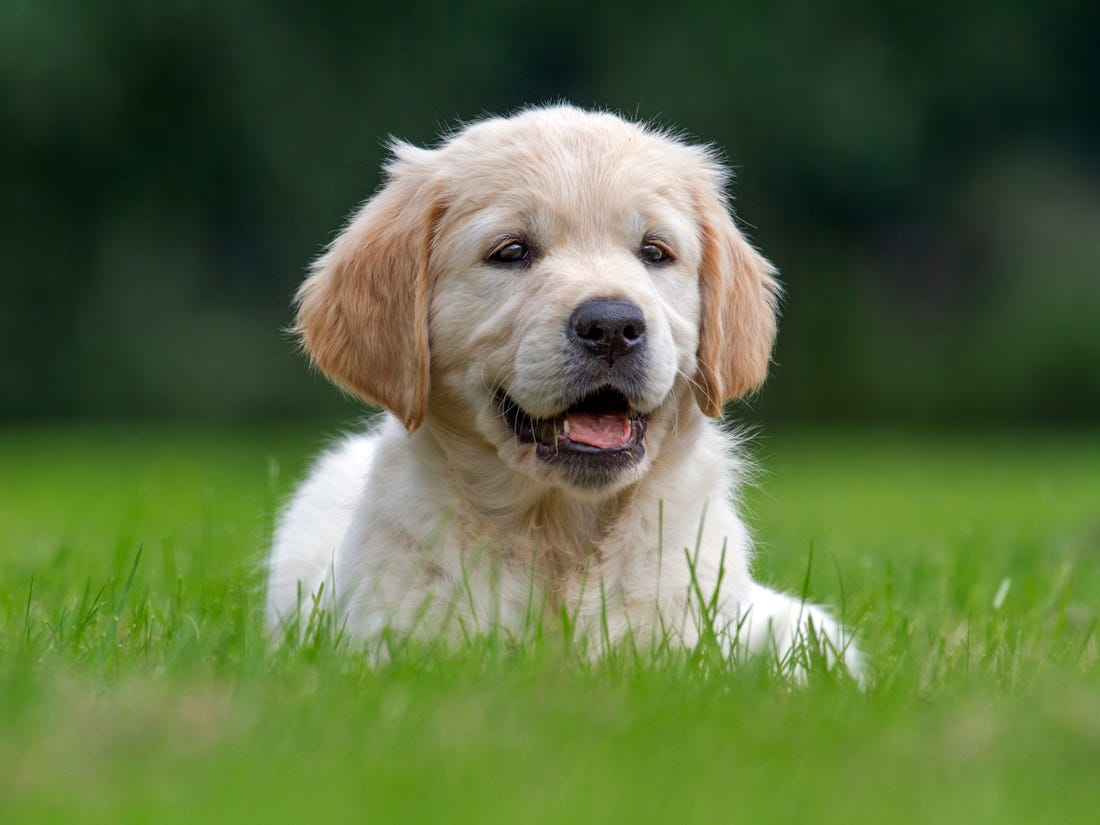

In [22]:
dog_path = "dog_url.jpg"
Image.open(dog_path)

In [24]:
## TO DO: code here, find the similar image

## Online inference

In [33]:
import requests
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Set the embedding server URL
url = "https://refinance-qui-missing-jet.trycloudflare.com"

# Define texts to compare
texts = [
    "một con mèo đang ngủ trong nhà.",
    "Một con mèo đang ngủ trên ghế sofa.",
    "Một con chó đang đi ngủ",
    "hà nội đang mưa rất to"
]

# Function to get embedding from server
def get_embedding(text):
    payload = {
        "model": "gme-qwen2-vl",
        "input": [{"text": text}]
    }
    response = requests.post(url + "/v1/embeddings", json=payload).json()
    return response.get("data", [])[0]['embedding']

# Get embeddings for all texts
embeddings = [get_embedding(t) for t in texts]

# Compute cosine similarity matrix
sim_matrix = cosine_similarity(np.array(embeddings))

# Print similarity results
print("\nCosine Similarity Matrix:")
for i in range(len(texts)):
    for j in range(len(texts)):
        print(f"Similarity[{i},{j}] = {sim_matrix[i][j]:.4f}")
    print()


Cosine Similarity Matrix:
Similarity[0,0] = 1.0000
Similarity[0,1] = 0.8089
Similarity[0,2] = 0.7113
Similarity[0,3] = 0.3646

Similarity[1,0] = 0.8089
Similarity[1,1] = 1.0000
Similarity[1,2] = 0.6879
Similarity[1,3] = 0.3057

Similarity[2,0] = 0.7113
Similarity[2,1] = 0.6879
Similarity[2,2] = 1.0000
Similarity[2,3] = 0.4509

Similarity[3,0] = 0.3646
Similarity[3,1] = 0.3057
Similarity[3,2] = 0.4509
Similarity[3,3] = 1.0000



## Online inference for multimodel embeddings

In [26]:
import base64
import mimetypes
from pathlib import Path
from typing import List

import requests

MODEL_NAME = "gme-qwen2-vl"
SGLANG_URL = "https://refinance-qui-missing-jet.trycloudflare.com"  # <-- bạn đặt sau

def embed_text(text: str) -> List[float]:
    """
    Embed a text string via SGLang OpenAI-compatible /v1/embeddings.
    Returns: embedding vector (List[float])
    """
    url = f"{SGLANG_URL}/v1/embeddings"
    payload = {
        "model": MODEL_NAME,
        "input": [{"text": text}],
    }

    r = requests.post(url, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data["data"][0]["embedding"]

def embed_image(image_path: str | Path) -> List[float]:
    """
    Embed a local image file via SGLang OpenAI-compatible /v1/embeddings.
    We send the image as a data URL in 'image_url' (base64).
    Returns: embedding vector (List[float])
    """
    path = Path(image_path)
    mime = mimetypes.guess_type(str(path))[0] or "application/octet-stream"
    b64 = base64.b64encode(path.read_bytes()).decode("utf-8")
    data_url = f"data:{mime};base64,{b64}"

    url = f"{SGLANG_URL}/v1/embeddings"
    payload = {
        "model": MODEL_NAME,
        "input": [{"image_url": data_url, "mime_type": mime}],
    }

    r = requests.post(url, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data["data"][0]["embedding"]


In [27]:
import glob
import numpy as np
import faiss

images_dir = f"{DATASET_DIR}/images"
img_paths = sorted(glob.glob(f"{images_dir}/*.jpg"))
print("Num images:", len(img_paths))

# 1) gọi embed_image cho từng ảnh -> gom thành ma trận (N, D)
img_vecs = []
for p in img_paths:
    v = embed_image(p)
    img_vecs.append(v)

img_vecs = np.array(img_vecs, dtype="float32")
print("Embeddings shape:", img_vecs.shape)

# 2) tạo FAISS index (cosine) = normalize trước + IndexFlatIP
#    (nếu server đã trả normalized thì bước normalize này vẫn OK)
faiss.normalize_L2(img_vecs)

D = img_vecs.shape[1]
index = faiss.IndexFlatIP(D)
index.add(img_vecs)
print("FAISS ntotal:", index.ntotal)

Num images: 24
Embeddings shape: (24, 1536)
FAISS ntotal: 24


In [28]:
def search_by_text(query: str, k: int = 5):
    q = np.array([embed_text(query)], dtype="float32")
    faiss.normalize_L2(q)
    scores, ids = index.search(q, k)
    return [(img_paths[i], float(scores[0][r])) for r, i in enumerate(ids[0])]

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
import os

def show(results, title):
    plt.figure(figsize=(14, 4))
    for i, (path, score) in enumerate(results):
        img = Image.open(path).convert("RGB")
        ax = plt.subplot(1, len(results), i + 1)
        ax.imshow(img)
        ax.set_title(f"{os.path.basename(path)}\n{score:.3f}")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

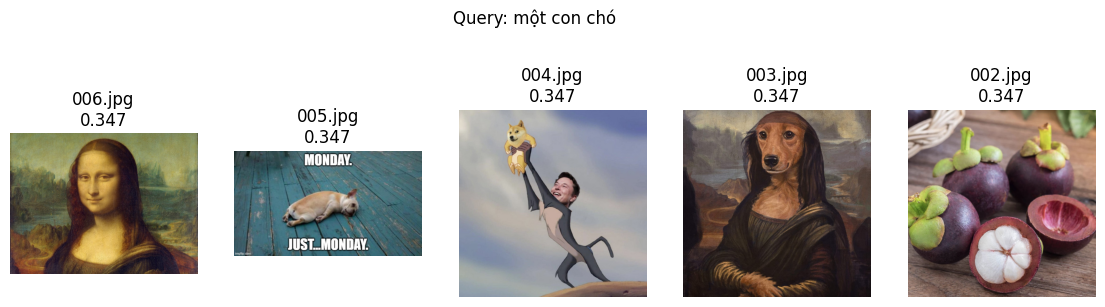

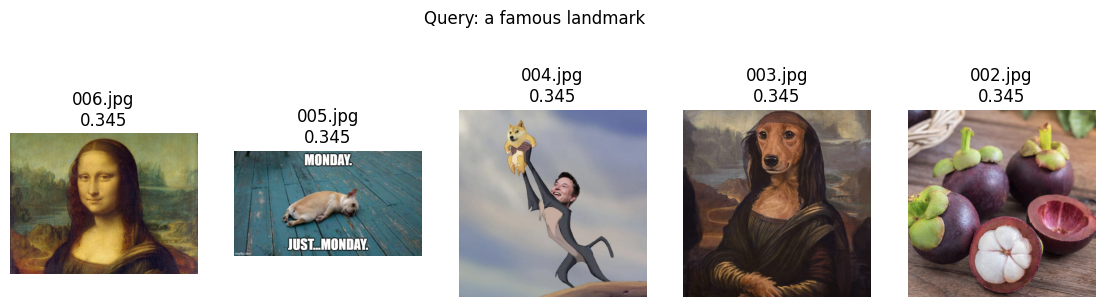

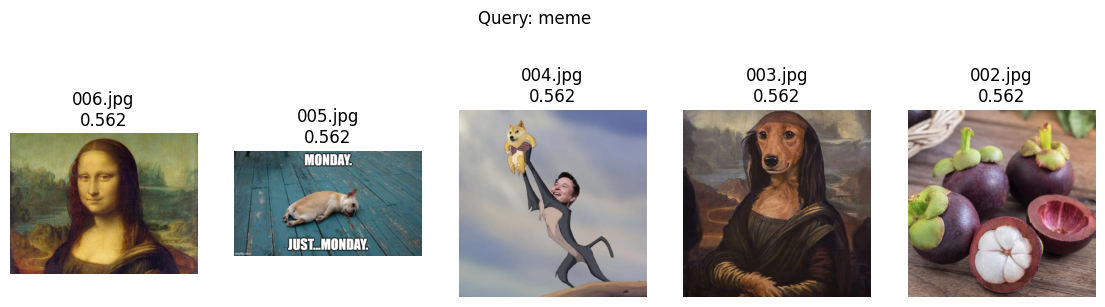

In [30]:
show(search_by_text("một con chó", 5), "Query: một con chó")
show(search_by_text("a famous landmark", 5), "Query: a famous landmark")
show(search_by_text("meme", 5), "Query: meme")

In [31]:
def search_by_image(image_path: str | Path, k: int = 5):
    q = np.array([embed_image(image_path)], dtype="float32")
    faiss.normalize_L2(q)
    scores, ids = index.search(q, k)
    return [(img_paths[i], float(scores[0][r])) for r, i in enumerate(ids[0])]

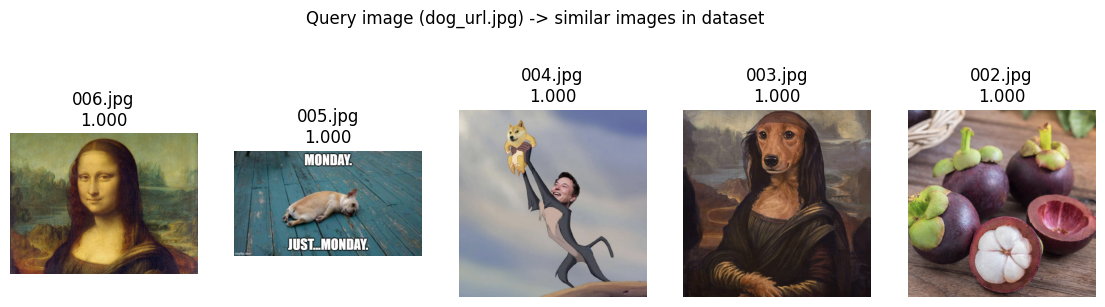

In [32]:
show(search_by_image("dog_url.jpg", 5), "Query image (dog_url.jpg) -> similar images in dataset")